### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3
rho_steel *= 9.81

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.25966406, 0.26301383, 0.0274139 , 0.93222613, 0.92146235,
       0.9616765 , 0.62076664, 0.19002594, 0.06102601, 0.10449443,
       0.98757382, 0.49907975, 0.30990389, 0.26899342, 0.96656321,
       0.47088256, 0.39136867, 0.65447286, 0.77106511, 0.78422957])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 12)

coefs = [1, 1, 1, 1, 1, 1]
k500 = 6
lift_reduction_factor=1
vessel_motion_calibration_coefficient = 5e2 # to control dynamics

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.98609196,  0.        ,  0.16062899],
        [ 0.        ,  1.        , -0.25675589],
        [-0.16620065,  0.        ,  0.95303449]],

       [[ 0.74871171,  0.        ,  0.6400993 ],
        [ 0.        ,  1.        , -0.25999191],
        [-0.66289575,  0.        ,  0.7229641 ]],

       [[ 0.98982862,  0.        ,  0.14221145],
        [ 0.        ,  1.        , -0.02741047],
        [-0.1422649 ,  0.        ,  0.9894567 ]],

       [[ 0.85876516,  0.        ,  0.30539675],
        [ 0.        ,  1.        , -0.80294881],
        [-0.5123694 ,  0.        ,  0.51186525]],

       [[ 0.99614082,  0.        ,  0.05307031],
        [ 0.        ,  1.        , -0.79648669],
        [-0.08776941,  0.        ,  0.60232259]],

       [[ 0.97192984,  0.        ,  0.13460924],
        [ 0.        ,  1.        , -0.82015192],
        [-0.23527086,  0.        ,  0.55608558]],

       [[ 0.9448434 ,  0.        ,  0.26641749],
        [ 0.        ,  1.        , -0.58165894],
        

In [36]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [37]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.5097033 ,  0.28037416,  0.04532969],
       [ 0.99208467,  0.41054469,  0.26897822],
       [ 0.11392624,  0.3937874 ,  0.71150077],
       [ 1.08215908,  0.35265622, -0.09218832],
       [ 1.03943654, -0.52250117,  0.48190044],
       [ 0.46621843,  0.24096076, -0.01050687],
       [ 0.6873329 ,  0.65502476,  0.16244964],
       [ 0.98794535,  0.87314853,  0.29957338],
       [ 0.31468402,  0.76184753, -0.15722098],
       [ 1.25753341,  0.74072467, -0.18782296],
       [ 0.68286628, -0.41618611, -0.45021707],
       [ 0.23477287, -0.33759347,  0.70686113],
       [ 0.32420946,  0.48460283, -0.0423268 ],
       [ 0.4052631 , -0.05042155,  0.11616462],
       [ 0.21685016,  0.51400608,  0.24128408],
       [ 0.44272844,  0.39585423, -0.05507008],
       [ 1.17886248, -0.18672992,  0.19610063],
       [ 0.96265571,  0.32798879, -0.35686123],
       [ 0.51409798,  0.05918727,  0.33102083],
       [ 0.15061485, -0.21064824,  0.40942825]])

In [38]:
def dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ):
    return (np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((ddφ,ddθ,ddψ), axis=1))+
        np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1)))

In [39]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.88615924,  0.26231161,  0.57286004],
       [ 1.3442858 ,  0.63872967, -0.10579215],
       [ 0.7888518 ,  0.9892759 ,  1.49331256],
       [ 1.54078389,  0.97810708, -0.68703223],
       [ 1.98060288, -0.88987551,  0.73079224],
       [ 1.35857565,  0.32073633,  0.02831454],
       [ 1.09828426,  0.86412759,  0.14324629],
       [ 1.86010297,  1.2897361 , -0.30730892],
       [ 0.90486284,  1.39117106, -0.15866752],
       [ 1.75486418,  0.52392575, -0.42173923],
       [ 1.06608192, -0.44650251,  0.08617305],
       [ 1.20437674,  0.33162095,  1.16432772],
       [ 0.94371595,  1.15024   , -0.16521396],
       [ 1.04510569,  0.37698629,  0.44100094],
       [ 0.76531761,  0.7400865 ,  0.38823342],
       [ 1.53398142,  0.74566874,  0.29803605],
       [ 1.45935987, -0.55130612,  0.74328659],
       [ 1.66135465,  0.61622166, -0.75610798],
       [ 0.70642074,  0.99182212,  0.44466279],
       [ 0.82874897,  0.28990497,  0.86473202]])

In [40]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [41]:
phi(x,y,z)

array([[0.61681596, 0.48325846, 0.79193363],
       [0.4436734 , 0.29754704, 0.6100923 ],
       [0.7886855 , 0.57696988, 0.81038581],
       [0.57093569, 0.00464888, 0.8193917 ],
       [0.12128563, 0.83331164, 0.47036997],
       [0.64224834, 0.39967123, 0.99629153],
       [0.71621133, 0.88636317, 0.34951143],
       [0.03322778, 0.56687748, 0.41667399],
       [0.69899257, 0.47589116, 0.77208937],
       [0.39216256, 0.73601103, 0.84630372],
       [0.27661357, 0.54427204, 0.27511277],
       [0.58255048, 0.93065437, 0.95500506],
       [0.39037171, 0.80664939, 0.45285346],
       [0.60832336, 0.87379601, 0.97773018],
       [0.11562394, 0.75847222, 0.33076243],
       [0.80424982, 0.76344966, 0.15438369],
       [0.33567525, 0.78263905, 0.41672246],
       [0.75644042, 0.84929018, 0.52098546],
       [0.78854717, 0.83646646, 0.53222789],
       [0.13150533, 0.96174625, 0.68601901]])

In [42]:
theta(φ,θ,ψ)

array([[0.25966406, 0.16697547, 0.40710718],
       [0.26301383, 0.72467982, 0.46918946],
       [0.0274139 , 0.14274921, 0.28699814],
       [0.93222613, 0.53794161, 0.8098333 ],
       [0.92146235, 0.08788249, 0.85001346],
       [0.9616765 , 0.23749724, 0.16579463],
       [0.62076664, 0.33368019, 0.74376889],
       [0.19002594, 0.26505293, 0.51774924],
       [0.06102601, 0.67229699, 0.60056351],
       [0.10449443, 0.84922178, 0.26545997],
       [0.98757382, 0.95303124, 0.45791439],
       [0.49907975, 0.19289675, 0.34777536],
       [0.30990389, 0.72656258, 0.40247829],
       [0.26899342, 0.54777527, 0.98172809],
       [0.96656321, 0.5901408 , 0.70151292],
       [0.47088256, 0.4673299 , 0.13030935],
       [0.39136867, 0.42942215, 0.21983687],
       [0.65447286, 0.59301594, 0.68300214],
       [0.77106511, 0.19351112, 0.4734879 ],
       [0.78422957, 0.33716791, 0.4356752 ]])

In [43]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [44]:
ω(x,y,z)

array([[ 0.84635625,  0.02517175,  0.28540927],
       [ 0.58572462,  0.03565876,  0.39673657],
       [ 0.97256331,  0.00205994,  0.04846801],
       [ 0.5741346 , -0.43816644,  0.68677099],
       [ 0.42714845,  0.77640228,  0.22419554],
       [ 0.90206122, -0.19710472,  0.48499871],
       [ 0.65707232,  0.65689787, -0.38822486],
       [ 0.25166101,  0.55303487,  0.33346126],
       [ 0.89209167, -0.0209073 ,  0.20512519],
       [ 0.81567543,  0.41256416,  0.31634976],
       [ 0.37368108,  0.46913887,  0.08318391],
       [ 0.98755746,  0.40525305,  0.0091355 ],
       [ 0.57245739,  0.63432407,  0.00792798],
       [ 1.00570075,  0.31503064,  0.0485889 ],
       [ 0.30991374,  0.72031333,  0.15896558],
       [ 0.65507734,  0.65224547, -0.47870597],
       [ 0.51546487,  0.64536784,  0.04228547],
       [ 0.78412694,  0.49171859, -0.31767195],
       [ 0.80686751,  0.45894128, -0.33393521],
       [ 0.63304161,  0.8717909 ,  0.28121538]])

In [45]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])


        return np.array(np.dot(np.dot(Cθ,Cφ),Cψ) )
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [46]:
Ret(φ,θ,ψ)

array([[[ 0.92239531, -0.35126231,  0.16062899],
        [ 0.38268073,  0.88748626, -0.25675589],
        [-0.05236735,  0.29830005,  0.95303449]],

       [[ 0.7457315 , -0.18481728,  0.6400993 ],
        [ 0.43661394,  0.86126214, -0.25999191],
        [-0.50324229,  0.47336043,  0.7229641 ]],

       [[ 0.95044646, -0.27645512,  0.14221145],
        [ 0.28296806,  0.95873758, -0.02741047],
        [-0.12876569,  0.06629348,  0.9894567 ]],

       [[ 0.89015   , -0.33818013,  0.30539675],
        [ 0.4316414 ,  0.41104612, -0.80294881],
        [ 0.14600919,  0.84656676,  0.51186525]],

       [[ 0.70994658, -0.70225308,  0.05307031],
        [ 0.45427163,  0.3990567 , -0.79648669],
        [ 0.53815717,  0.58957134,  0.60232259]],

       [[ 0.99044729,  0.02990839,  0.13460924],
        [ 0.09442472,  0.56430027, -0.82015192],
        [-0.10048945,  0.82502769,  0.55608558]],

       [[ 0.82431649, -0.49952383,  0.26641749],
        [ 0.55074794,  0.59862308, -0.58165894],
        

In [47]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [48]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-0.11718752, -0.04186662,  0.11682232],
       [ 0.31864666, -0.23022562, -0.11944438],
       [-0.05228639,  0.16582358, -0.06717504],
       [-0.09173497, -0.89466395,  0.06899503],
       [-0.6363604 , -0.40068717,  0.8739475 ],
       [ 0.15472328, -1.03954939,  0.31728386],
       [-0.36104662, -0.01045912,  0.7663734 ],
       [-0.18024136, -0.11725999,  0.1739035 ],
       [ 0.28568663, -0.02384209, -0.24394403],
       [ 0.62464861, -0.18853692, -0.12548515],
       [ 0.51570169, -0.39620706,  0.26532516],
       [-0.16461351, -0.40483731,  0.49492856],
       [ 0.20839708, -0.18873239,  0.15653749],
       [-0.30309135, -0.30015833,  0.45682818],
       [ 0.16104557, -0.3628901 ,  0.7758479 ],
       [ 0.14582414, -0.16020636,  0.03258413],
       [ 0.12692778, -0.176218  ,  0.22870996],
       [ 0.0213487 , -0.37729327,  0.58405171],
       [-0.22733564, -0.29163405,  0.7951612 ],
       [-0.01020773, -0.57354218,  0.80601909]])

In [49]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-0.03215514, -0.04132274,  0.03745799],
       [ 0.16330974, -0.18994466,  0.20182964],
       [-0.00126907, -0.0118235 ,  0.00600208],
       [-0.05700073, -0.90745201,  0.66840147],
       [-0.53866524, -0.42132915,  0.6275044 ],
       [ 0.04867006, -0.28758626,  0.12965492],
       [-0.19648961, -0.35497946,  0.3232507 ],
       [-0.03026274, -0.08012668,  0.05212662],
       [ 0.0920027 , -0.22657845,  0.24429298],
       [ 0.13660401, -0.06091482,  0.14109786],
       [ 0.88941087, -1.00685911,  0.17734603],
       [-0.03015711, -0.08888581,  0.09257869],
       [ 0.18443742, -0.1707249 ,  0.16618152],
       [-0.08420846, -0.52967158,  0.31861421],
       [ 0.13100656, -0.91877425,  0.59240542],
       [ 0.1038799 , -0.11266961,  0.02869055],
       [ 0.06659809, -0.08828605,  0.05389259],
       [ 0.0714875 , -0.52281181,  0.38542941],
       [-0.10040364, -0.24658461,  0.26428259],
       [ 0.00217099, -0.34208211,  0.26082861]])

In [50]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [51]:
ne(x, y, z, φ, θ, ψ)

array([[-1.17187518e+08, -4.18666151e+07,  1.16822323e+08],
       [ 3.18646658e+08, -2.30225621e+08, -1.19444377e+08],
       [-5.22863896e+07,  1.65823583e+08, -6.71750367e+07],
       [-9.17349723e+07, -8.94663954e+08,  6.89950273e+07],
       [-6.36360396e+08, -4.00687175e+08,  8.73947495e+08],
       [ 1.54723276e+08, -1.03954939e+09,  3.17283855e+08],
       [-3.61046622e+08, -1.04591215e+07,  7.66373402e+08],
       [-1.80241362e+08, -1.17259987e+08,  1.73903503e+08],
       [ 2.85686627e+08, -2.38420940e+07, -2.43944025e+08],
       [ 6.24648613e+08, -1.88536920e+08, -1.25485147e+08],
       [ 5.15701686e+08, -3.96207064e+08,  2.65325164e+08],
       [-1.64613508e+08, -4.04837305e+08,  4.94928564e+08],
       [ 2.08397083e+08, -1.88732391e+08,  1.56537488e+08],
       [-3.03091348e+08, -3.00158325e+08,  4.56828177e+08],
       [ 1.61045575e+08, -3.62890103e+08,  7.75847900e+08],
       [ 1.45824137e+08, -1.60206365e+08,  3.25841323e+07],
       [ 1.26927783e+08, -1.76218003e+08

In [52]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 2.17322563e+07, -7.79619237e+07, -6.13968859e+06],
       [-3.40342876e+07,  1.11924579e+08, -3.06526088e+08],
       [-5.55033095e+07, -1.00794550e+07,  1.83201437e+07],
       [-6.42190036e+07, -6.65085846e+07, -9.47806883e+08],
       [-3.42140416e+08, -1.11596491e+09, -7.60775036e+08],
       [-1.07149581e+08, -3.24382479e+08, -1.01055591e+09],
       [-7.19723896e+07, -7.34339133e+08, -4.39288867e+07],
       [ 8.07861396e+07, -1.34521612e+08, -6.97512519e+06],
       [-1.44791985e+08,  2.25847786e+08, -1.91641578e+08],
       [-8.50006834e+07,  9.34673435e+07, -5.63553581e+08],
       [-1.09640714e+08, -5.46150254e+08, -6.02455814e+08],
       [ 9.56820407e+07, -3.04983255e+08, -2.17643617e+08],
       [ 1.09739056e+08, -5.93156539e+07, -2.17609755e+08],
       [ 3.31513865e+08, -5.32491369e+08, -1.29923538e+08],
       [-6.50590066e+07, -8.28433083e+08, -3.73981423e+08],
       [-4.07455773e+06, -3.12186883e+07, -1.35257974e+08],
       [ 8.28790134e+07, -9.79640726e+07

In [53]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [54]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 3214458.59302028,   624483.01826354,  3448308.51964893],
       [ 4972493.73333923,  6026943.56241882,  1648563.88631334],
       [  679494.82780863,  1348824.62034668,  2800721.95956883],
       [10478837.80404943, -1123130.7628763 ,  -631186.26348902],
       [ 9630167.30222538, -5891419.16046561,  4311061.01169082],
       [ 9569995.78956521,  1015204.55621833, -1340584.52564992],
       [ 7846803.01227273,  -989396.3247898 ,  3683209.1203749 ],
       [ 3165783.22760121,  1672581.95436289,  4408950.9758195 ],
       [ 4210719.0345176 ,  6356697.34924481,  4309960.62384726],
       [ 2672370.17731818,  8215331.41178246,   959468.50472646],
       [ 7775890.2021018 ,  5708136.29520599, -6589784.93317424],
       [ 5483607.01135154,   264452.90586177,  2040165.51737388],
       [ 4862728.63445116,  6038199.42153134,   806358.61907622],
       [ 7225232.40396035,  2868700.41150022,  6678593.60878115],
       [10248660.22923128,   128391.39765306, -2067298.76883175],
       [ 4

In [55]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[ 2.91038305e-11, -2.63341014e-10,  2.91038305e-11],
       [ 1.16415322e-10, -2.20229052e-10,  0.00000000e+00],
       [ 1.74622983e-10, -1.08687841e-10,  1.45519152e-11],
       [-4.36557457e-11, -1.89942489e-11, -4.65661287e-10],
       [ 4.65661287e-10,  1.41444369e-10, -9.31322575e-10],
       [ 0.00000000e+00, -3.79672453e-11, -1.16415322e-10],
       [-2.32830644e-10, -6.86739008e-11,  4.65661287e-10],
       [-1.16415322e-10,  2.17245964e-10,  0.00000000e+00],
       [ 4.65661287e-10, -5.35600521e-10,  4.65661287e-10],
       [ 4.65661287e-10, -1.37582638e-10,  0.00000000e+00],
       [ 0.00000000e+00,  1.20645088e-09,  9.31322575e-10],
       [ 1.45519152e-11, -1.76476537e-10, -2.91038305e-11],
       [-5.82076609e-11, -4.33424206e-11,  4.65661287e-10],
       [ 4.65661287e-10,  8.28650111e-10, -6.98491931e-10],
       [ 2.18278728e-11, -5.34496674e-10,  8.73114914e-11],
       [-5.82076609e-11,  1.99627086e-10,  2.32830644e-10],
       [ 0.00000000e+00, -1.22679878e-12

In [56]:
def fD(dx,dy,dz): 
    
    A=np.vstack([np.abs(dx-dv1_curr)*dx-(dv1_curr),
                 ((dy-dv2_curr)**2+(dz-dv3_curr)**2)**0.5*(dy-dv2_curr),
                 ((dy-dv2_curr)**2+(dz-dv3_curr)**2)**0.5*(dz-dv3_curr)])
    
    return 1/2*d0*qw*np.dot(DT, A)*9.81

In [57]:
fD(dx,dy,dz).T

array([[1545.0518677 , 2242.61598738,  640.89574385],
       [2621.02747332, 1991.12246421,  590.87465358],
       [1508.7939174 ,  519.66880859, 2022.42393872],
       [  13.36403169, 1857.77635277,  625.06737086],
       [1309.3945402 , 2511.9656384 , 1952.3778117 ],
       [   6.7185734 , 1437.97558719, 2009.96284388],
       [1870.23373396, 1954.47957571,  413.04775821],
       [3213.14824399, 2605.70675262, 3330.62784725],
       [ 206.78422596, 5055.00665375, 4959.91217898],
       [3300.46387174, 1969.97925708,   23.71050345],
       [ 608.5643617 , 3572.38453654, 1622.18746055],
       [1134.81019004, 3403.42944601, 4117.90162602],
       [2745.81152039, 1998.65041927, 2937.25353439],
       [ 214.97234422, 3669.46664353, 2832.03404871],
       [1509.25011381,  168.00948231, 1761.09929504],
       [1143.24570457, 1165.76868442, 1373.50606883],
       [2260.22533176,  747.46613099,  898.54423014],
       [1222.81487741, 1249.22113148, 2074.88495839],
       [ 732.28261876,  576.

In [58]:
fg_e = lift_reduction_factor*np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [59]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [60]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [61]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 25029.53149783],
       [ 5845.36330569,  5845.36330569, 20624.52270442],
       [ 5845.36330569,  5845.36330569, 25476.52559824],
       [ 5845.36330569,  5845.36330569, 25694.68864863],
       [ 5845.36330569,  5845.36330569, 17239.82397185],
       [ 5845.36330569,  5845.36330569, 29979.99212182],
       [ 5845.36330569,  5845.36330569, 14312.09046033],
       [ 5845.36330569,  5845.36330569, 15939.06751087],
       [ 5845.36330569,  5845.36330569, 24548.81483789],
       [ 5845.36330569,  5845.36330569, 26346.61777432],
       [ 5845.36330569,  5845.36330569, 12509.82280699],
       [ 5845.36330569,  5845.36330569, 28979.84962792],
       [ 5845.36330569,  5845.36330569, 16815.49600846],
       [ 5845.36330569,  5845.36330569, 29530.35344299],
       [ 5845.36330569,  5845.36330569, 13857.90618687],
       [ 5845.36330569,  5845.36330569,  9585.22545154],
       [ 5845.36330569,  5845.36330569, 15940.24170645],
       [ 5845.36330569,  5845.3

In [62]:
def ne_hat(x,y,z,dx,dy,dz):
    return -fg_e.T - fD(dx,dy,dz) #- sigma(x,y,z).T

In [63]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-1545.0518677 , -2242.61598738,  -365.72459217],
       [-2621.02747332, -1991.12246421,  -315.70350191],
       [-1508.7939174 ,  -519.66880859, -1747.25278704],
       [  -13.36403169, -1857.77635277,  -349.89621918],
       [-1309.3945402 , -2511.9656384 , -1677.20666002],
       [   -6.7185734 , -1437.97558719, -1734.7916922 ],
       [-1870.23373396, -1954.47957571,  -137.87660653],
       [-3213.14824399, -2605.70675262, -3055.45669557],
       [ -206.78422596, -5055.00665375, -4684.74102731],
       [-3300.46387174, -1969.97925708,   251.46064823],
       [ -608.5643617 , -3572.38453654, -1347.01630887],
       [-1134.81019004, -3403.42944601, -3842.73047434],
       [-2745.81152039, -1998.65041927, -2662.08238272],
       [ -214.97234422, -3669.46664353, -2556.86289704],
       [-1509.25011381,  -168.00948231, -1485.92814337],
       [-1143.24570457, -1165.76868442, -1098.33491715],
       [-2260.22533176,  -747.46613099,  -623.37307846],
       [-1222.81487741, -1249.2

In [64]:
def Jrho(Ret,Jrho0): 
    ans=  Ret @ Jrho0 @ Ret
    return ans

In [65]:
RET = Ret(φ, θ, ψ)

In [66]:
Jrho(RET,Jrho0)

array([[[  69.95683686,  -53.99119184,   54.45220214],
        [  71.94980616,   50.0029957 ,  -65.57921519],
        [  -3.39654988,   85.17123477,  173.15474706]],

       [[ -16.88284106,   30.89951646,  145.09308332],
        [  96.33136746,   41.49389023,  -32.03745527],
        [ -89.62600856,  118.51404962,   60.01592742]],

       [[  78.84965906,  -50.89483186,   42.41662668],
        [  54.72971644,   83.73155014,   -4.02810856],
        [ -35.8442118 ,   23.03450363,  193.79200513]],

       [[  73.55759389,    7.70388042,   85.60342219],
        [  32.71743034, -133.651319  , -102.02302922],
        [  64.48573963,  116.52567857,  -11.11469855]],

       [[  24.21308312,  -71.62235089,   66.09432034],
        [ -35.34813233, -109.89388436, -125.32188565],
        [ 129.81768129,   56.75741211,   28.45594442]],

       [[  95.67563165,   26.86126907,   25.85024426],
        [  31.16398425, -103.20372081, -136.22508349],
        [ -13.33879647,  138.01298855,   -7.17125007]],

### Static solution

In [67]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [68]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [69]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [70]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [71]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [72]:
delta_x=horizontal_length/(N-1)

In [73]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [74]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [75]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

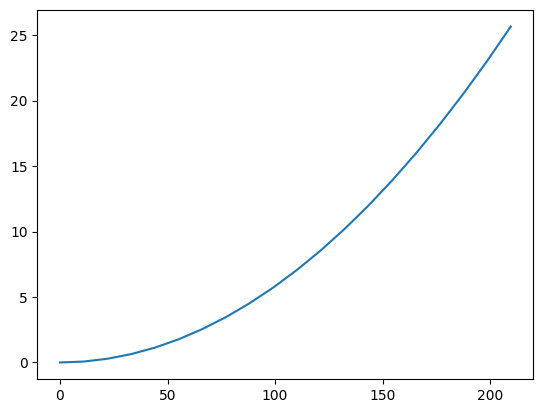

In [76]:
plt.plot(x0, z0)
plt.show()

In [77]:
q0=np.zeros(12*N)

In [78]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [79]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/Ws[0]).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [80]:
root_ = root(static_func, q0, method='df-sane')

In [81]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 1.984e+01  1.984e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.488e+02  1.599e+02 ...  0.000e+00  0.000e+00]
     nit: 277
    nfev: 1000
  method: df-sane

In [82]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [83]:
# q0 = root_.x                                            # start from static solution

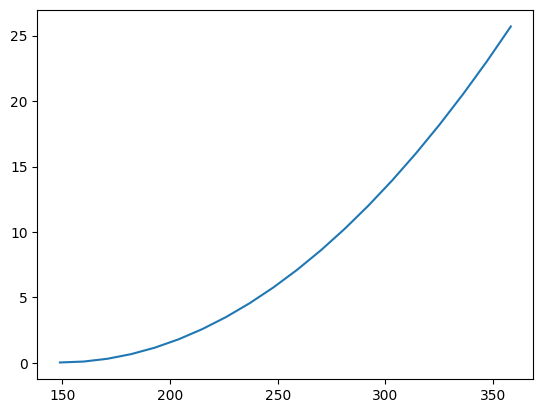

In [84]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [85]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [86]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
    return np.dot(np.dot(R.T,kprime),R)

In [87]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [88]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
        
        
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
    glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [89]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(6)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4, 0.0145e-4, 0.0175e-4,0.0114e-4],
        vessel_movement=[ 0, 0, 0, 0, 0,0.0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                       ],
        coefs=[1,1,1,1,1,1])

In [90]:
d

array([-7.050e-06, -7.000e-08,  1.418e-05,  1.450e-06,  1.750e-06,
        1.140e-06, -7.050e-06,  3.350e-06,  8.930e-06,  1.450e-06,
        1.750e-06,  1.140e-06, -1.230e-05,  4.280e-06,  1.418e-05,
        1.450e-06,  1.750e-06,  1.140e-06, -2.490e-06, -7.000e-08,
        8.380e-06,  1.450e-06,  1.750e-06,  1.140e-06])

In [91]:
f

array([ 2.18575158e-15, -1.86923231e-17, -3.84067778e-15,  9.71445147e-17,
        4.94078553e-17, -1.38777878e-17, -5.59719372e-16, -2.94360890e-17,
        2.29749217e-17,  3.06625927e-19,  2.51331616e-17,  5.88721780e-17,
        1.93123512e-17,  1.42708111e-17,  1.72398987e-15, -2.85416222e-17,
        6.63802780e-17, -6.09863722e-20,  2.08166817e-17,  4.64478987e-17,
        2.42861287e-17,  1.38777878e-17,  3.17637355e-20, -1.38777878e-17])

In [92]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
    bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
    bc_val = [0]*3 + vessel_movement
    
    vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord,elcon,bc_node,bc_val,vessel_move, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [93]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1]
)

In [94]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.24041939e-03, -1.43432617e-02,  9.07897949e-03],
       [ 1.65176392e-03, -2.05535889e-02, -1.37329102e-02],
       [ 5.62191010e-04, -1.75781250e-02,  1.35650635e-02],
       [-8.59022141e-04, -1.35498047e-02, -1.24702454e-02],
       [ 3.62396240e-04, -2.19726562e-03,  9.94873047e-03],
       [ 3.72314453e-03,  9.64355469e-03,  2.19726562e-03],
       [-7.01904297e-04,  1.30767822e-02, -4.45556641e-03],
       [ 2.28404999e-04,  1.51367188e-02,  9.33074951e-03],
       [ 1.11389160e-03,  1.68457031e-02, -1.00708008e-02],
       [-8.69750977e-04,  1.70898438e-03,  6.95800781e-03],
       [ 5.11169434e-04, -7.14111328e-03, -5.85937500e-03],
       [-3.16619873e-04, -3.41796875e-03,  2.79426575e-03],
       [-1.67846680e-04, -7.81250000e-03, -1.22070312e-04],
       [ 1.52587891e-05, -6.95800781e-03,  1.83105469e-03],
       [ 3.88871318e-04, -8.44908442e-04, -1.96351835e-03],
       [-6.17447280e-04, -2.61666921e-03

In [95]:
mom

array([[-3.21578979e-03,  3.90505791e-03,  4.88281250e-04],
       [ 6.46400452e-03,  3.29589844e-03,  7.26318359e-03],
       [ 8.68225098e-03,  3.14331055e-03,  5.61523438e-03],
       [ 1.20086670e-02, -1.22070312e-04,  1.70898438e-03],
       [ 9.82666016e-03,  1.85852051e-02, -2.44140625e-03],
       [ 5.11550903e-03,  1.09863281e-02, -6.40869141e-04],
       [ 0.00000000e+00,  1.29623413e-02,  6.83593750e-03],
       [-4.01306152e-03, -1.92871094e-02,  3.05175781e-03],
       [-7.69042969e-03, -1.04751587e-02,  1.80664062e-02],
       [-6.39915466e-03, -1.24511719e-02,  5.85937500e-03],
       [-4.02832031e-03,  1.99508667e-03, -4.39453125e-03],
       [ 8.23974609e-04,  7.81250000e-03, -1.28173828e-02],
       [ 4.57763672e-03,  1.47018433e-02, -1.02539062e-02],
       [ 2.77709961e-03,  1.95312500e-03, -1.77001953e-03],
       [ 3.66210938e-03, -2.38800049e-03, -3.90625000e-03],
       [ 2.48869971e-03, -2.17015469e-04, -8.64054443e-04],
       [-1.29591884e-03, -2.47530247e-03

In [96]:
angle

array([[-3.79148708e-01,  2.40891300e-02, -4.15794643e-02],
       [-3.79148708e-01,  2.39020854e-02, -4.15793975e-02],
       [-3.78804363e-01,  2.33382763e-02, -4.15725692e-02],
       [-3.77771498e-01,  2.23922560e-02, -4.15390969e-02],
       [-3.75706277e-01,  2.10583820e-02, -4.14458495e-02],
       [-3.72265373e-01,  1.93308104e-02, -4.12464559e-02],
       [-3.67106137e-01,  1.72034896e-02, -4.08813179e-02],
       [-3.59886762e-01,  1.46701539e-02, -4.02776260e-02],
       [-3.50266449e-01,  1.17243172e-02, -3.93493791e-02],
       [-3.37905574e-01,  8.35926695e-03, -3.79974071e-02],
       [-3.22465843e-01,  4.56805748e-03, -3.61093968e-02],
       [-3.03610455e-01,  3.43503427e-04, -3.35599210e-02],
       [-2.81004255e-01, -4.32182685e-03, -3.02104702e-02],
       [-2.54313890e-01, -9.43561796e-03, -2.59094872e-02],
       [-2.23207954e-01, -1.50058143e-02, -2.04924042e-02],
       [-1.87357136e-01, -2.10406272e-02, -1.37816821e-02],
       [-1.46434363e-01, -2.75485414e-02

### Vessle Simulation

In [97]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [98]:
Number*sampleTime

600.0

In [99]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [100]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [101]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

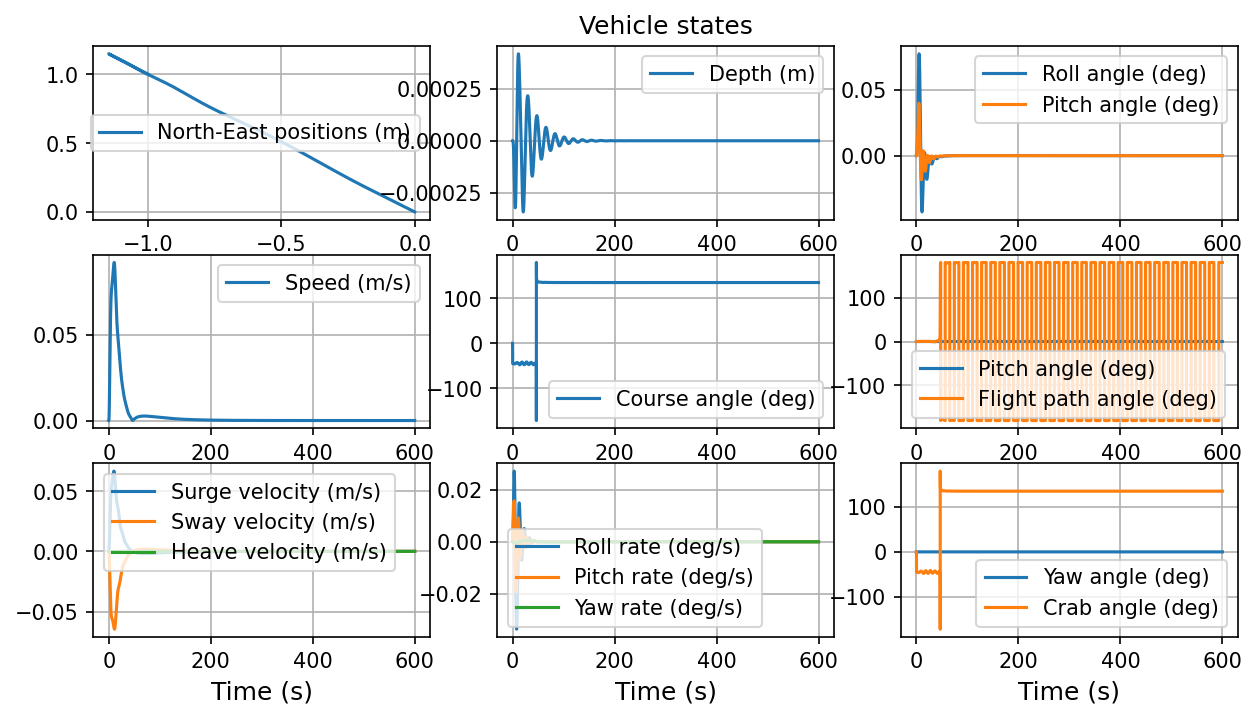

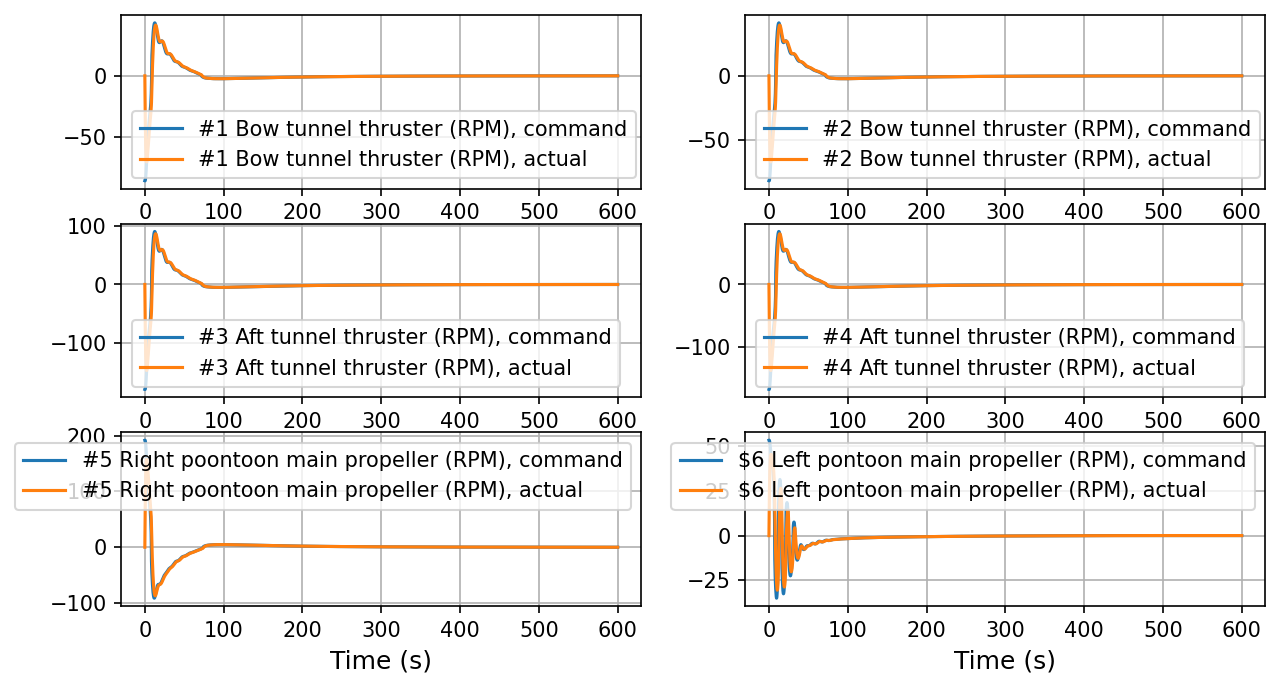

In [102]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [103]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

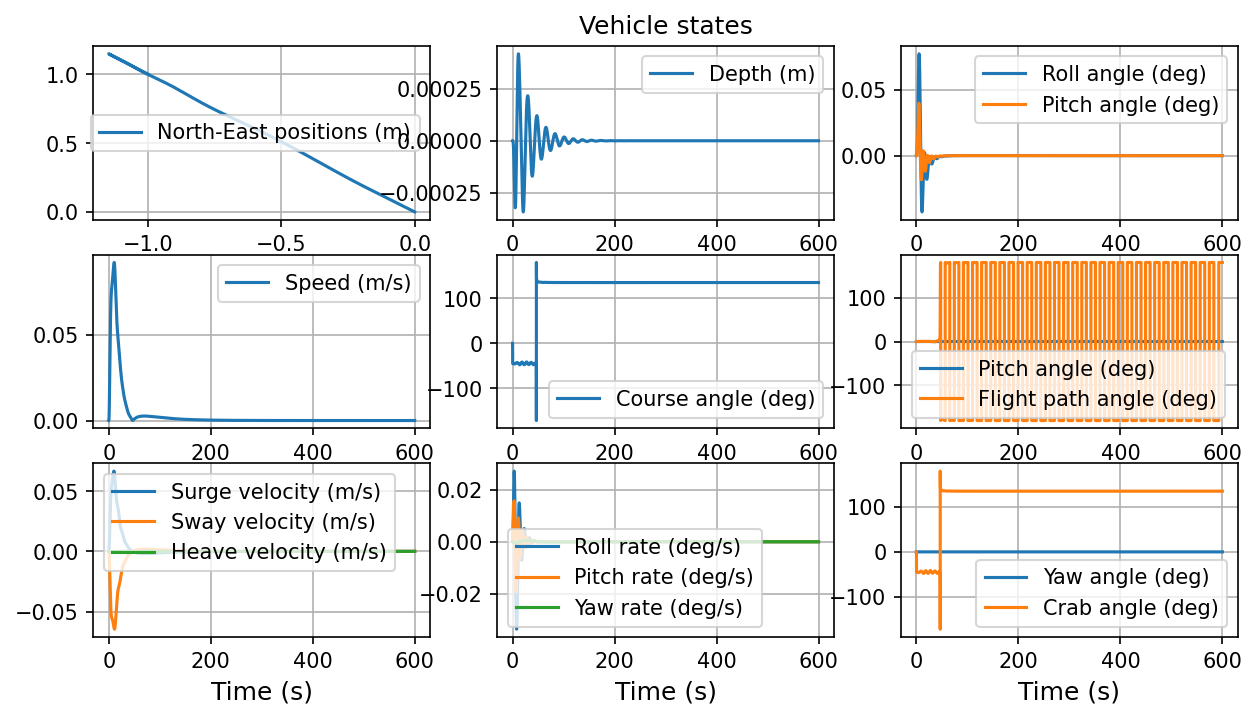

In [104]:
plotVehicleStates(simTime, simData, 3)

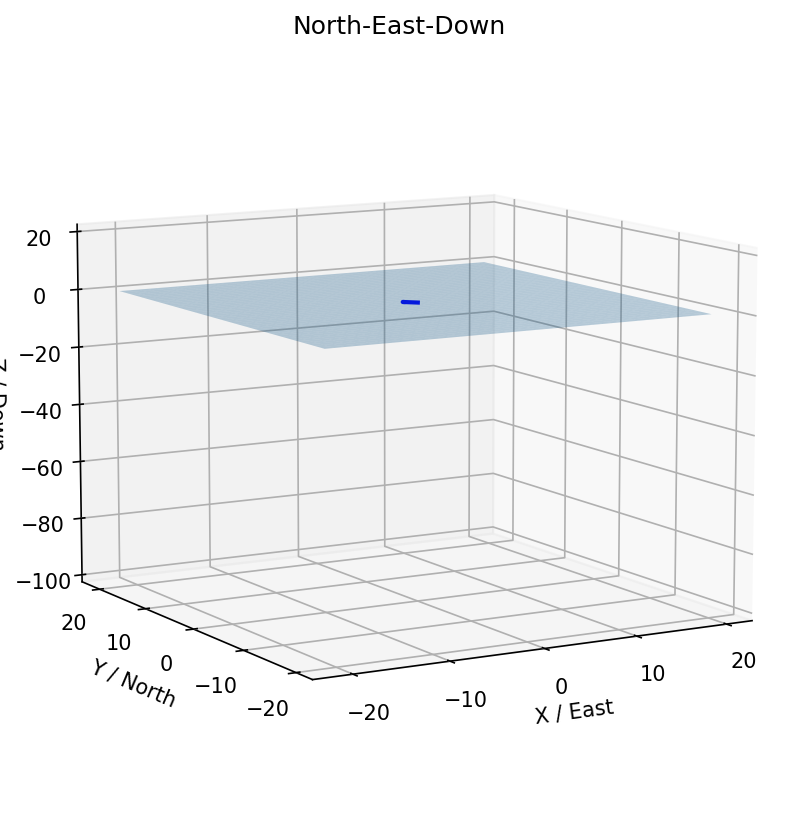

In [105]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [106]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [107]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

In [108]:
def inert(M, m, X):
    sum_=M
    ans=[]
    for i in range(len(X)-1,-1,-1):
        sum_+=m
        ans.append(np.array(sum_).copy())
    return np.array(ans)  

In [109]:
# V_rho=np.zeros(Jrho0.shape)
# np.fill_diagonal(V_rho, vessel_inertia)

In [110]:
# M_t=inert(vessel_mass*9.81,mp*9.81, x0)
# Jrho1=inert(V_rho, Jrho0, x0)

### Dynamics

In [111]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)

    vessel_movement/=calibr
    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_movement), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - Z0)


############################################################
#     ddx,ddy, ddz = (Z/(M_t.reshape(-1, 1))).T
    ddx,ddy, ddz = (Z/Ws[0]).T    
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0)

    A0 = Jrho(RET,Jrho0)
#     A0 = Jrho(RET,Jrho1) 
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [112]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.000001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

In [113]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.776098218877745e-07  Iteration wall-clock time:  0:00:00.606747
Physical time:  1.0068133414206595  Iteration wall-clock time:  0:00:22.390570
Physical time:  2.023926817883034  Iteration wall-clock time:  0:00:18.300330
Physical time:  3.0071823803684326  Iteration wall-clock time:  0:00:47.946526
Physical time:  4.005820734991439  Iteration wall-clock time:  0:00:38.260564
Physical time:  5.049664608540047  Iteration wall-clock time:  0:00:19.867788
Physical time:  6.060669083043672  Iteration wall-clock time:  0:00:17.578060
Physical time:  7.013644664766302  Iteration wall-clock time:  0:00:16.186888
Physical time:  8.00066633418093  Iteration wall-clock time:  0:00:19.719881
Physical time:  9.00909094859288  Iteration wall-clock time:  0:00:21.376712
Physical time:  10.015493570543134  Iteration wall-clock time:  0:00:25.542313
Physical time:  11.00978951203644  Iteration wall-clock time:  0:00:24.986608
0:05:00.215049


In [114]:
# max axial tension
T_.top_tension

817040.0797439977

In [115]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.0004894352990522201

### Results

In [116]:
fin=us_

In [117]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.776e-05 ...  1.191e+01  1.200e+01]
        y: [[ 0.000e+00 -3.370e-23 ... -1.075e-05 -1.090e-05]
            [ 1.103e+01  1.103e+01 ...  1.109e+01  1.109e+01]
            ...
            [ 0.000e+00 -4.510e-20 ...  5.359e-11  5.305e-11]
            [ 0.000e+00  6.448e-20 ...  2.693e-12  2.615e-12]]
      sol: None
 t_events: None
 y_events: None
     nfev: 824
     njev: 0
      nlu: 0

In [118]:
t=fin.t

In [119]:
fin=fin.y.T

In [120]:
t.shape, fin.shape

((123,), (123, 240))

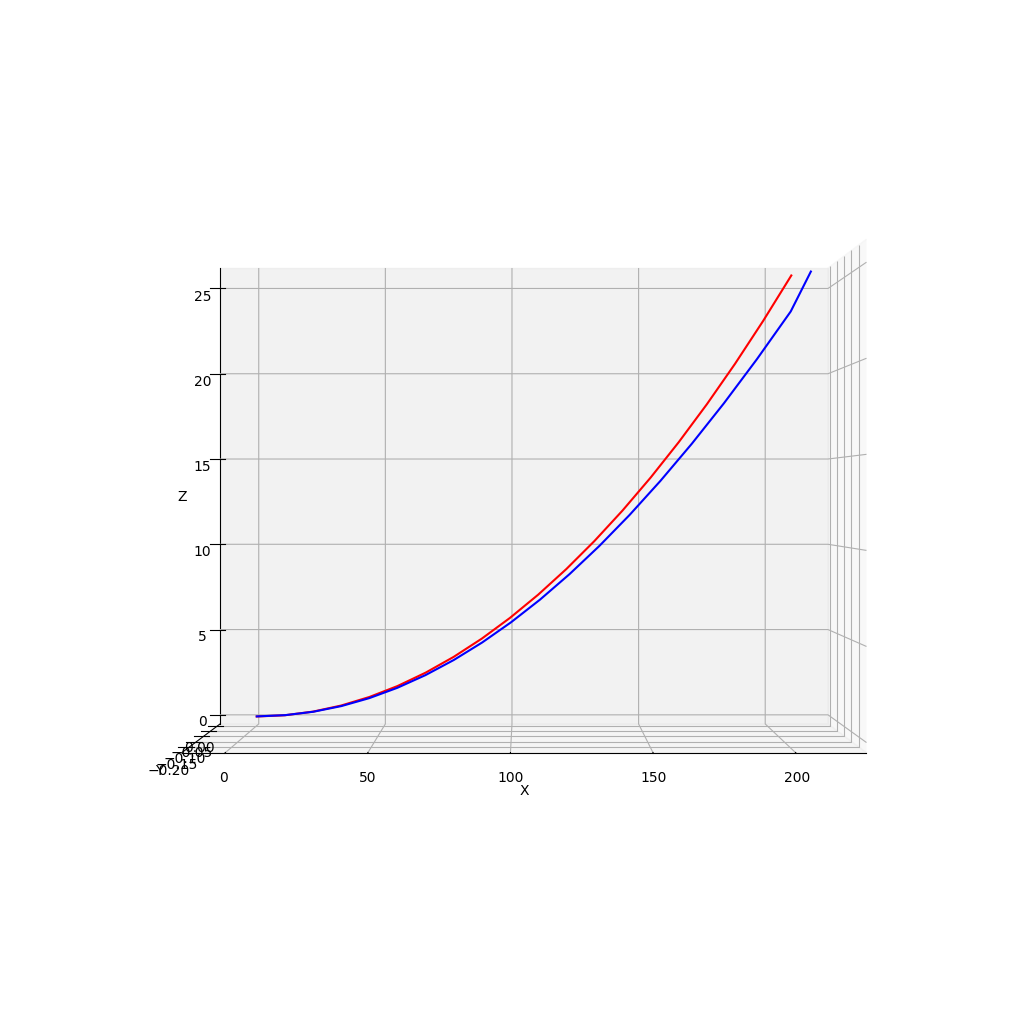

In [121]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
# ax.plot(x_fine, y_fine, z_fine, color='b')
# ax.view_init(-45,-45)
# ax.view_init(-30,-30)
ax.view_init(0,-90)
plt.show()

In [122]:
X,Y,Z

(array([-1.09046707e-05,  1.10943878e+01,  2.21831038e+01,  3.32673696e+01,
         4.43483810e+01,  5.54275565e+01,  6.65066324e+01,  7.75876073e+01,
         8.86725784e+01,  9.97634725e+01,  1.10861750e+02,  1.21968149e+02,
         1.33082667e+02,  1.44204527e+02,  1.55332226e+02,  1.66463948e+02,
         1.77597957e+02,  1.88732832e+02,  1.99867534e+02,  2.06108706e+02]),
 array([-1.09058338e-09,  6.92574359e-04, -9.13914369e-04, -4.13057055e-03,
        -8.54653111e-03, -1.41611349e-02, -2.10308005e-02, -2.92012998e-02,
        -3.87031536e-02, -4.95563056e-02, -6.17735578e-02, -7.53628717e-02,
        -9.03299052e-02, -1.06679611e-01, -1.24414822e-01, -1.43537090e-01,
        -1.64046513e-01, -1.85939991e-01, -2.09214366e-01, -2.28678460e-01]),
 array([4.45280575e-03, 7.33541049e-02, 2.79703041e-01, 6.25759755e-01,
        1.11191060e+00, 1.73784243e+00, 2.50335021e+00, 3.40838385e+00,
        4.45300998e+00, 5.63737177e+00, 6.96165081e+00, 8.42602674e+00,
        1.00306468e+

In [123]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [124]:
us=fin.T

In [125]:
us.shape

(240, 123)

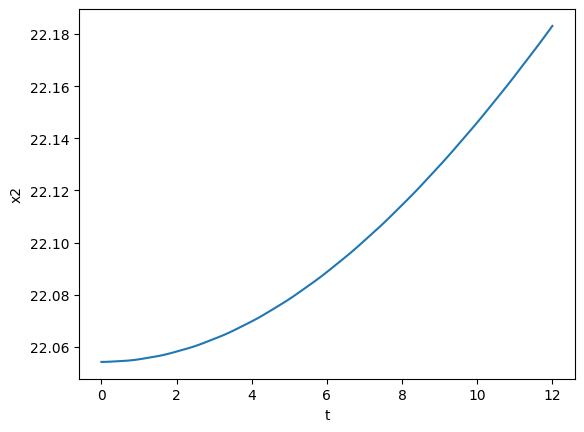

In [126]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

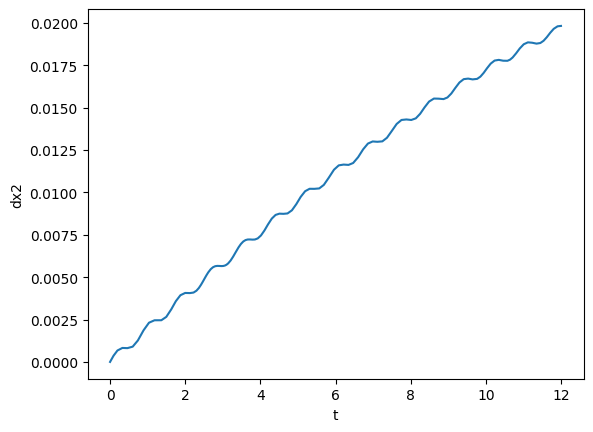

In [127]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

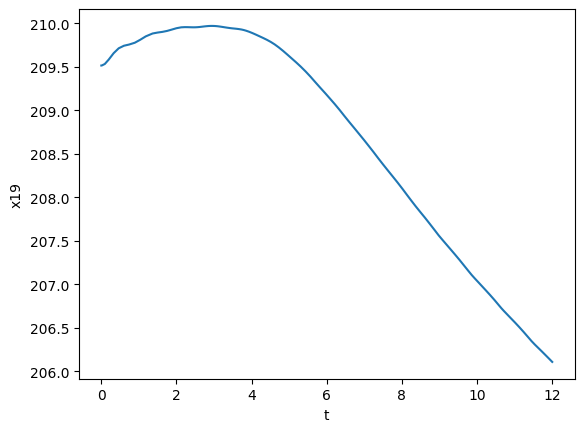

In [128]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

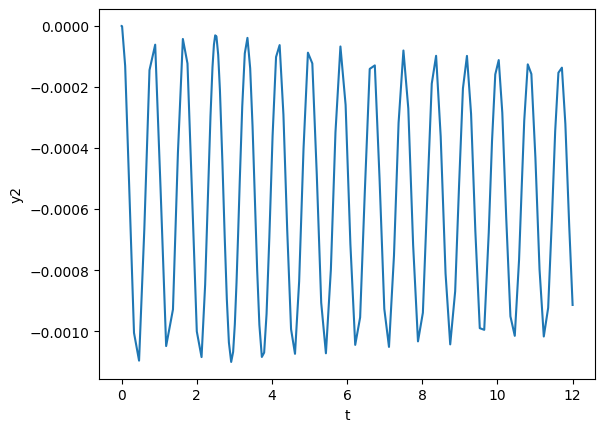

In [129]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

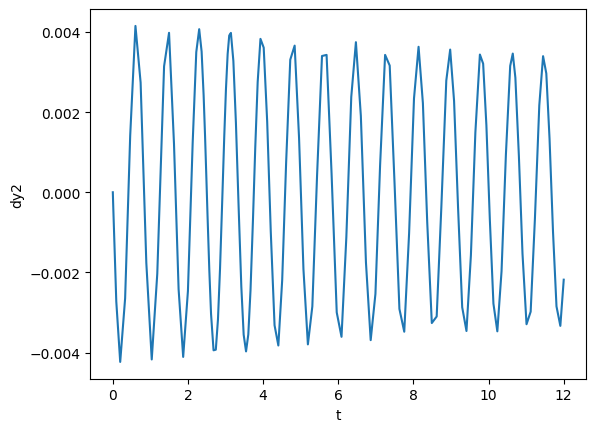

In [130]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

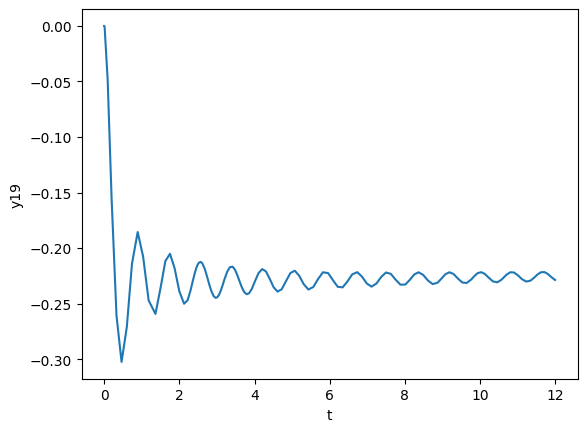

In [131]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

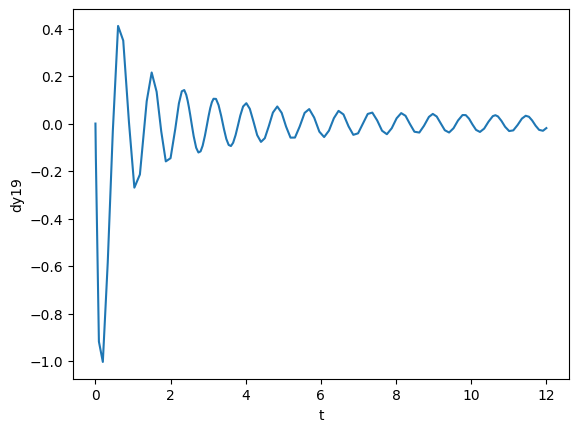

In [132]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

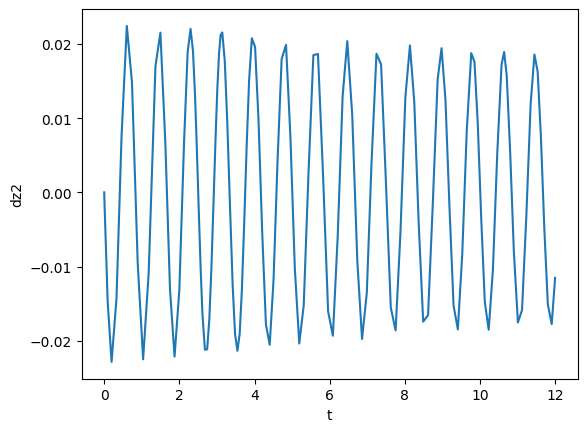

In [133]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

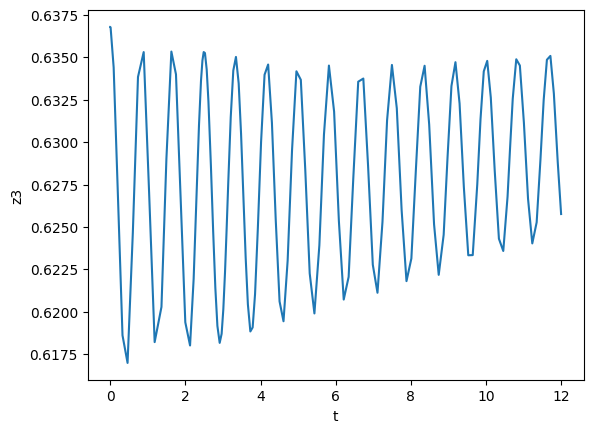

In [134]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

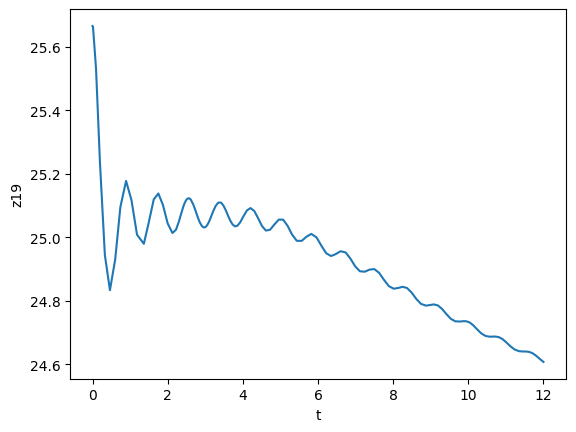

In [135]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

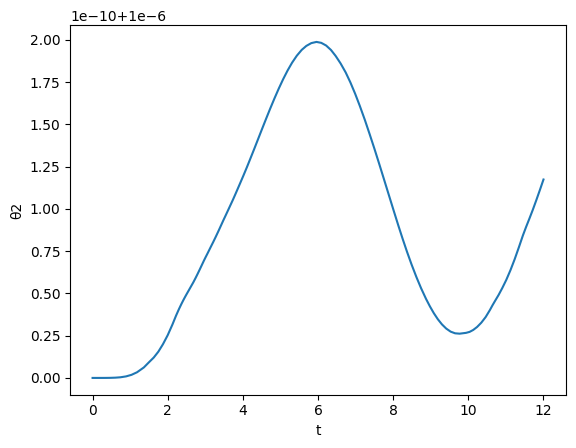

In [136]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

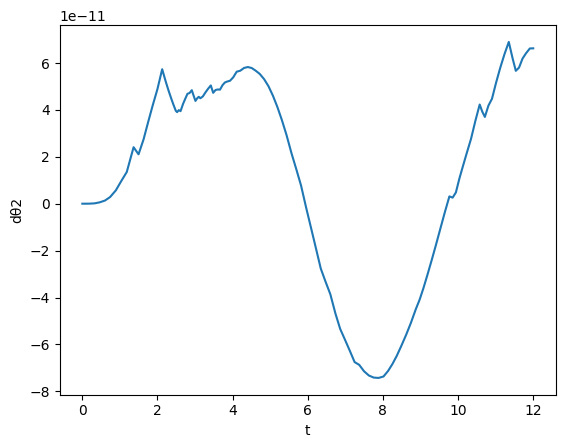

In [137]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

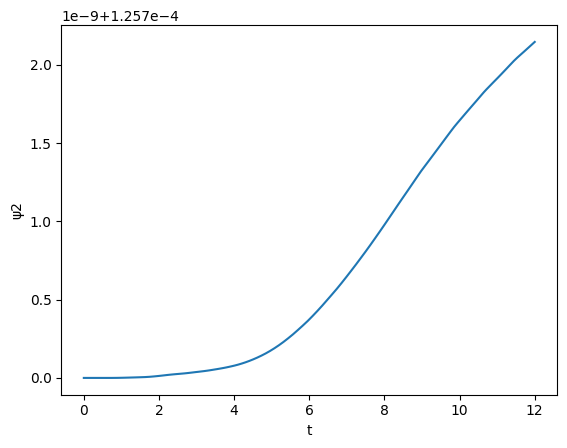

In [138]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

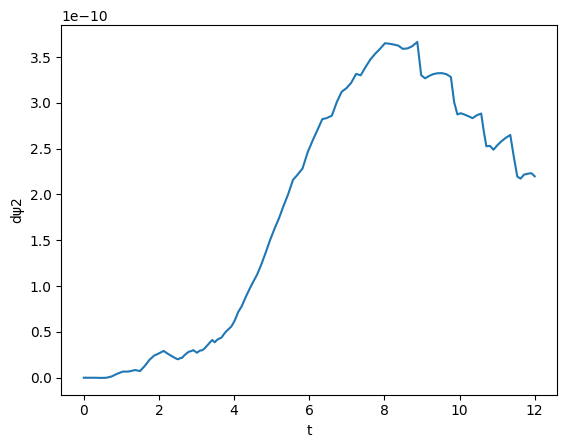

In [139]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

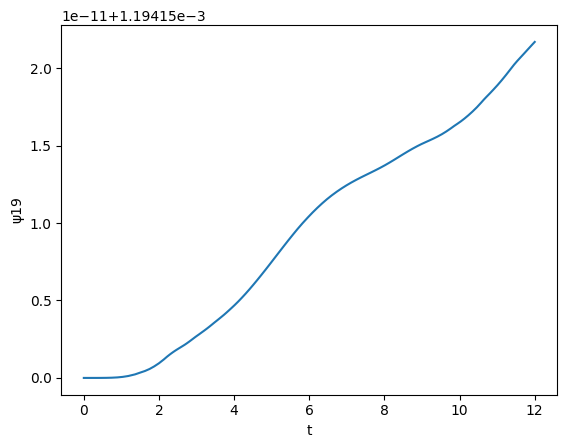

In [140]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [141]:
X010=us.T[:,0*N:1*N]

In [142]:
Y010=us.T[:,2*N:3*N]

In [143]:
Z010=us.T[:,4*N:5*N]

In [144]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()